In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

zip_path = "/content/drive/MyDrive/archive.zip"

import zipfile

extract_path = "/content/covid_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [ ]:
import os
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array

IMG_SIZE = (256, 256)

base_path = "/content/covid_dataset/Infection Segmentation Data/Infection Segmentation Data"

def load_split(split_name):
    images = []
    masks = []

    split_path = os.path.join(base_path, split_name)

    classes = ["COVID-19"]

    for cls in classes:
        img_dir = os.path.join(split_path, cls, "images")
        mask_dir = os.path.join(split_path, cls, "infection masks")

        img_files = os.listdir(img_dir)

        for file in img_files:
            img_path = os.path.join(img_dir, file)
            mask_path = os.path.join(mask_dir, file)

            img = load_img(img_path, target_size=IMG_SIZE, color_mode="grayscale")
            img = img_to_array(img) / 255.0

            mask = load_img(mask_path, target_size=IMG_SIZE, color_mode="grayscale")
            mask = img_to_array(mask) / 255.0

            images.append(img)
            masks.append(mask)

    return np.array(images), np.array(masks)

In [ ]:
train_imgs, train_masks = load_split("Train")
val_imgs, val_masks = load_split("Val")

print("Train images:", train_imgs.shape)
print("Train masks:", train_masks.shape)
print("Val images:", val_imgs.shape)
print("Val masks:", val_masks.shape)

Train images: (1864, 256, 256, 1)
Train masks: (1864, 256, 256, 1)
Val images: (466, 256, 256, 1)
Val masks: (466, 256, 256, 1)


In [ ]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D
from tensorflow.keras.layers import UpSampling2D, concatenate
from tensorflow.keras.models import Model

def build_pyimagesearch_unet(input_shape=(256,256,1)):
    inputs = Input(input_shape)

    c1 = Conv2D(32, (3,3), activation="relu", padding="same")(inputs)
    c1 = Conv2D(32, (3,3), activation="relu", padding="same")(c1)
    p1 = MaxPooling2D((2,2))(c1)

    c2 = Conv2D(64, (3,3), activation="relu", padding="same")(p1)
    c2 = Conv2D(64, (3,3), activation="relu", padding="same")(c2)
    p2 = MaxPooling2D((2,2))(c2)

    c3 = Conv2D(128, (3,3), activation="relu", padding="same")(p2)
    c3 = Conv2D(128, (3,3), activation="relu", padding="same")(c3)

    u1 = UpSampling2D((2,2))(c3)
    u1 = concatenate([u1, c2])
    c4 = Conv2D(64, (3,3), activation="relu", padding="same")(u1)
    c4 = Conv2D(64, (3,3), activation="relu", padding="same")(c4)

    u2 = UpSampling2D((2,2))(c4)
    u2 = concatenate([u2, c1])
    c5 = Conv2D(32, (3,3), activation="relu", padding="same")(u2)
    c5 = Conv2D(32, (3,3), activation="relu", padding="same")(c5)

    outputs = Conv2D(1, (1,1), activation="sigmoid")(c5)
    return Model(inputs, outputs)

model = build_pyimagesearch_unet()
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │     36,928 │ conv2d_2[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │    147,584 │ conv2d_4[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 128, 128,  │          0 │ conv2d_5[0][0]    │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 128, 128,  │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 192)              │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 128, 128,  │    110,656 │ concatenate[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 128, 128,  │     36,928 │ conv2d_6[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 256, 256,  │          0 │ conv2d_7[0][0]    │
│ (UpSampling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 256, 256,  │          0 │ up_sampling2d_1[… │
│ (Concatenate)       │ 96)               │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 256, 256,  │     27,680 │ concatenate_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 256, 256,  │      9,248 │ conv2d_8[0][0]  

 Total params: 470,977 (1.80 MB)

 Trainable params: 470,977 (1.80 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    train_imgs,
    train_masks,
    validation_data=(val_imgs, val_masks),
    epochs=20,
    batch_size=8
)

Epoch 1/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 51s 133ms/step - accuracy: 0.8597 - loss: 0.3962 - val_accuracy: 0.8615 - val_loss: 0.3250
Epoch 2/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 59s 108ms/step - accuracy: 0.8589 - loss: 0.3288 - val_accuracy: 0.8615 - val_loss: 0.3094
Epoch 3/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 26s 110ms/step - accuracy: 0.8610 - loss: 0.3110 - val_accuracy: 0.8624 - val_loss: 0.2914
Epoch 4/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 27s 115ms/step - accuracy: 0.8617 - loss: 0.2962 - val_accuracy: 0.8781 - val_loss: 0.2633
Epoch 5/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 27s 117ms/step - accuracy: 0.8718 - loss: 0.2760 - val_accuracy: 0.8828 - val_loss: 0.2527
Epoch 6/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 27s 115ms/step - accuracy: 0.8754 - loss: 0.2641 - val_accuracy: 0.8868 - val_loss: 0.2430
Epoch 7/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 27s 115ms/step - accuracy: 0.8824 - loss: 0.2508 - val_accuracy: 0.8920 - val_loss: 0.2283
Epoch 8/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 27s 116ms/step - accuracy: 0.8882 - loss: 0

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step


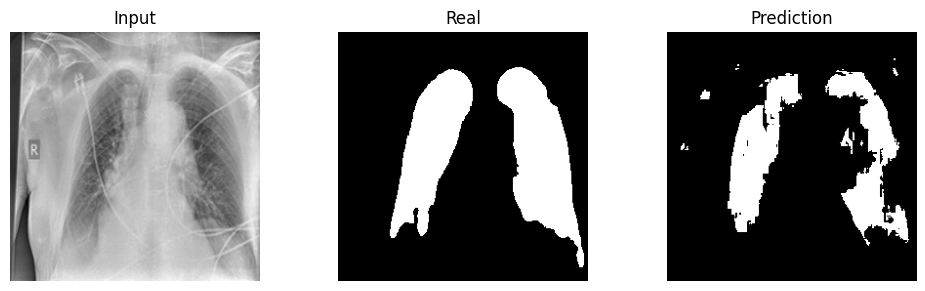

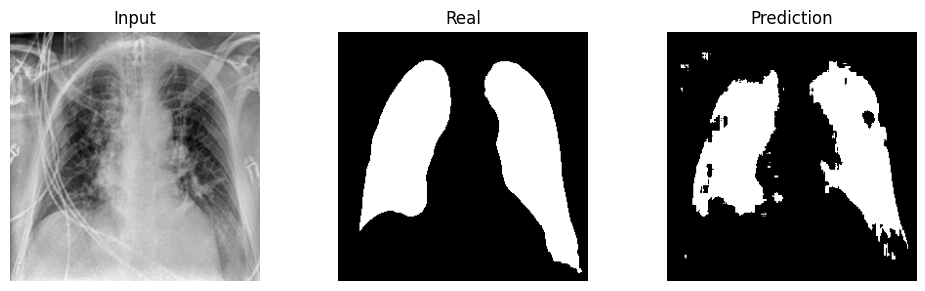

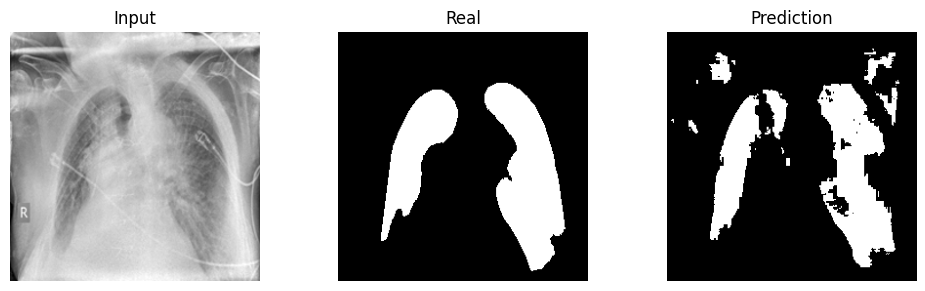

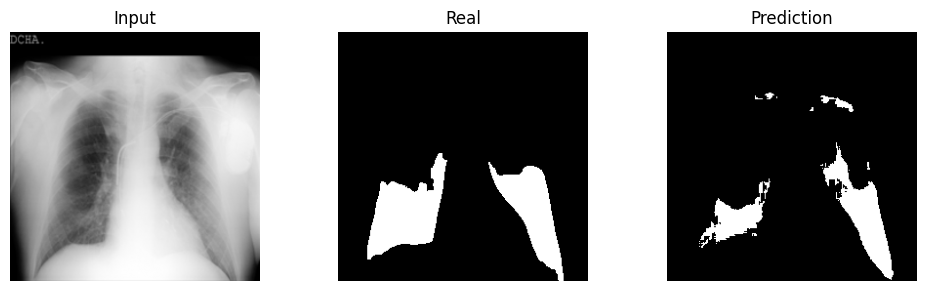

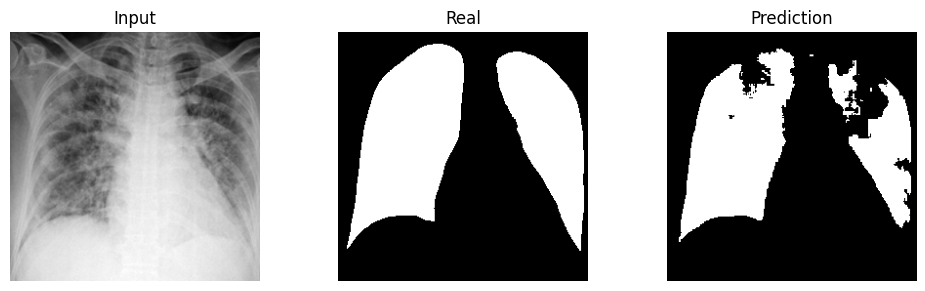

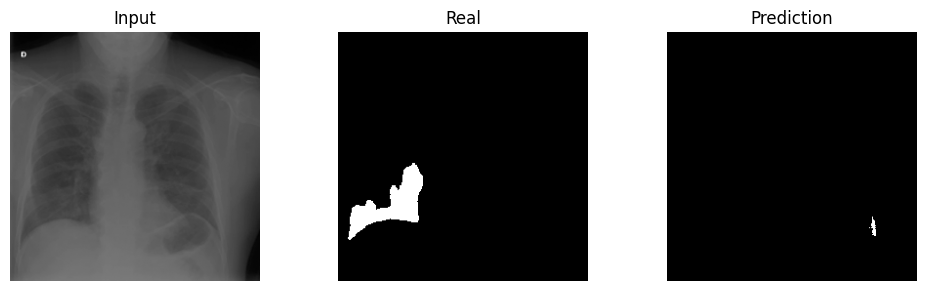

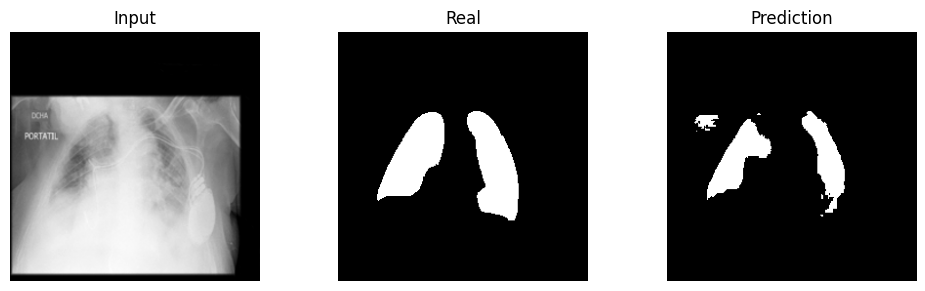

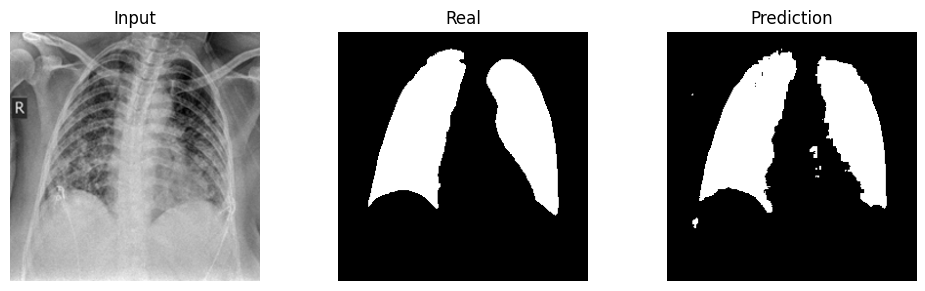

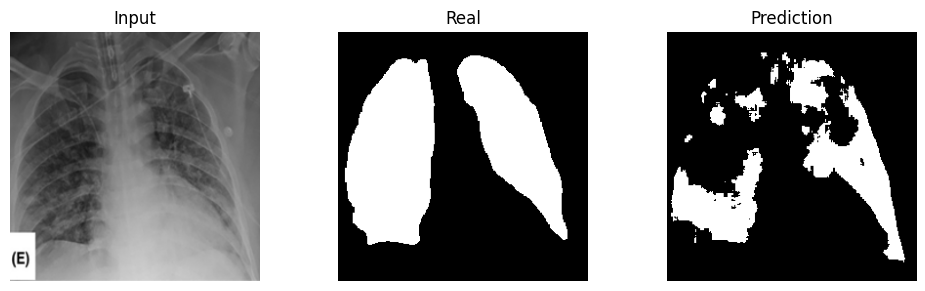

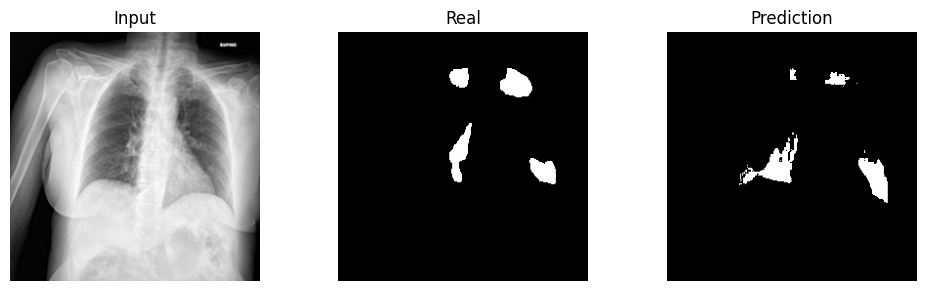

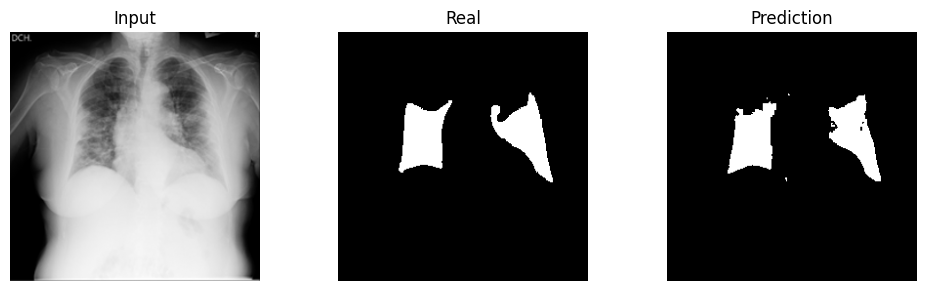

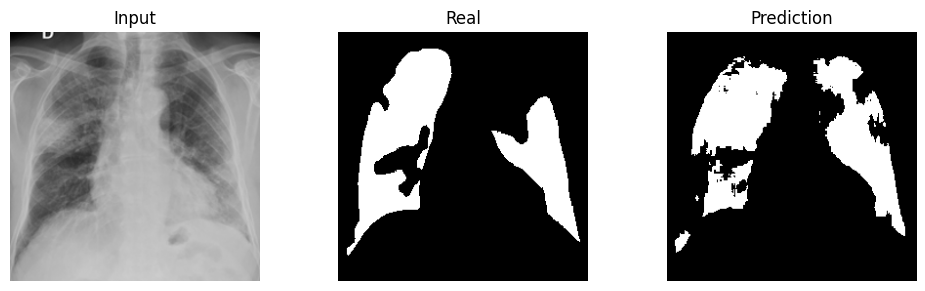

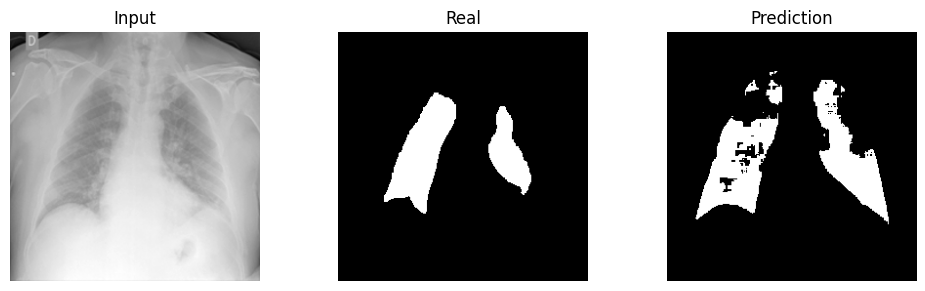

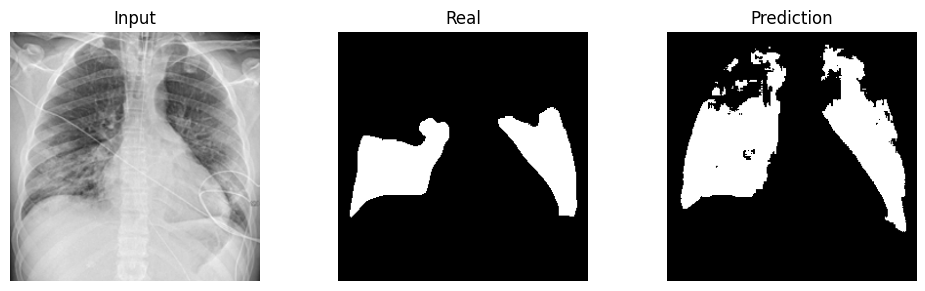

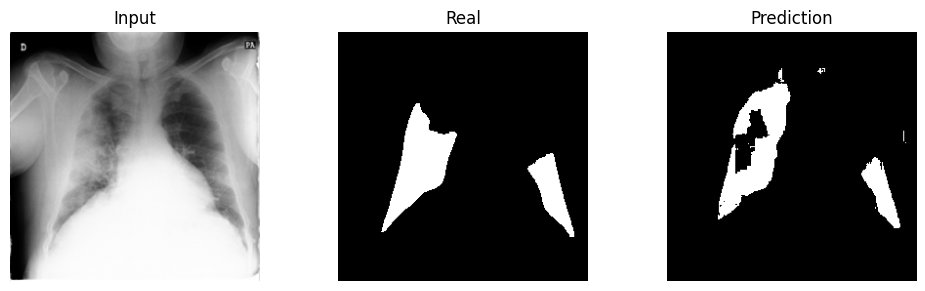

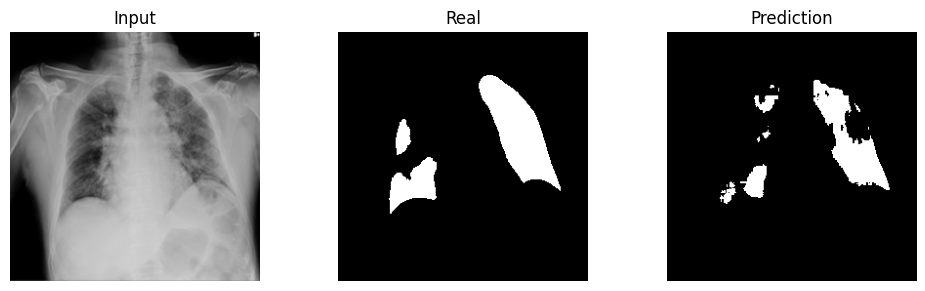

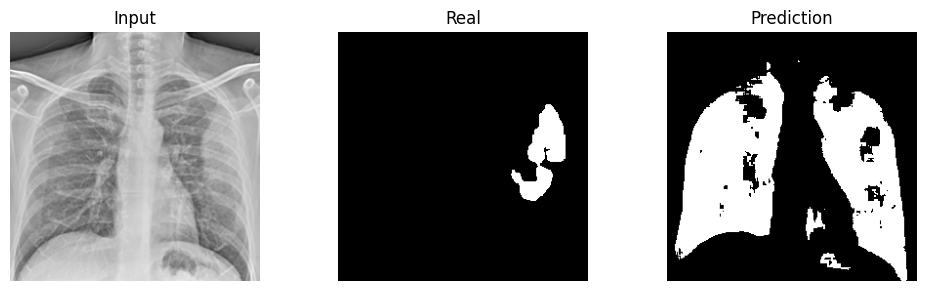

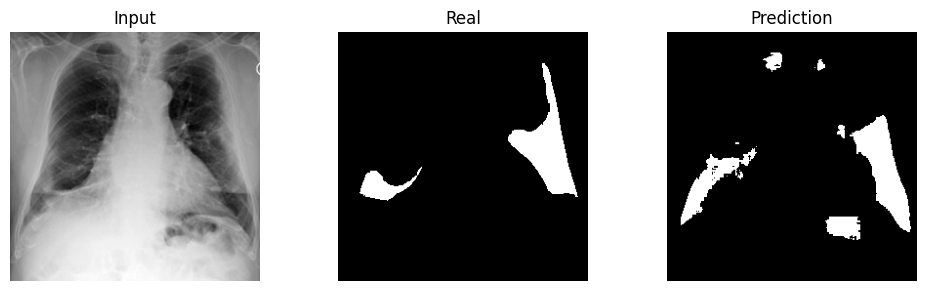

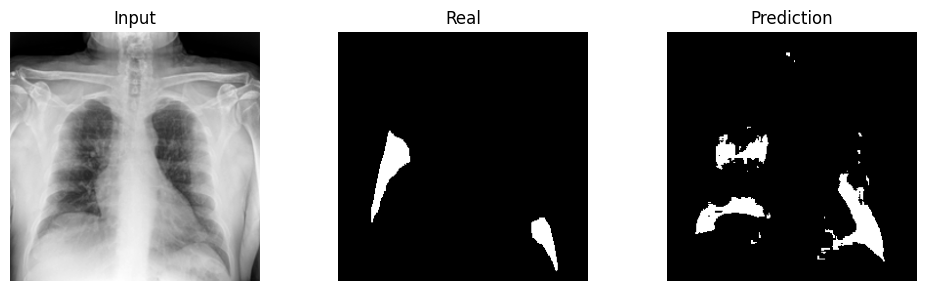

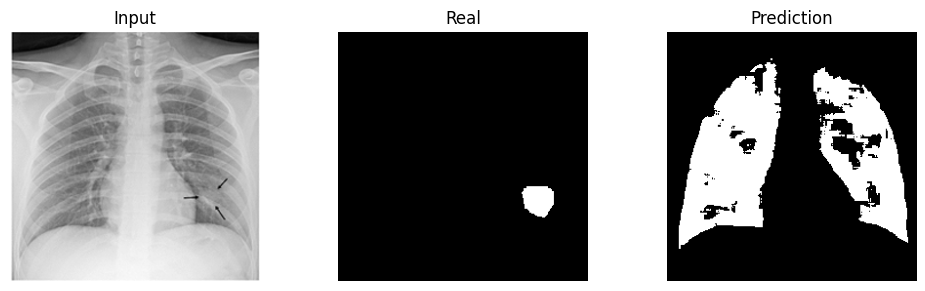

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

num_samples = 20

preds = model.predict(val_imgs[:num_samples])

for i in range(num_samples):
    plt.figure(figsize=(10,3))

    plt.subplot(1,3,1)
    plt.imshow(val_imgs[i].squeeze(), cmap='gray')
    plt.title("Input")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(val_masks[i].squeeze(), cmap='gray')
    plt.title("Real")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow((preds[i] > 0.5).astype(np.uint8).squeeze(), cmap='gray')
    plt.title("Prediction")
    plt.axis("off")

    plt.tight_layout()
    plt.show()